# 11 — PDE solvers (Fokker–Planck, Poisson)

CPU-only finite-difference solvers. Doc page:
[pde.rst](../../docs/source/algorithms/pde.rst).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — Diffusion d'une gaussienne (Fokker–Planck 1-D)

**Théorème (Fokker–Planck / Kolmogorov forward).** Pour la diffusion
$dX_t = \mu\,dt + \sigma\,dW_t$, la densité $p(t, x)$ vérifie
$$\partial_t p = -\mu\,\partial_x p + \tfrac{1}{2}\sigma^2\,\partial_{xx} p.$$

**Équation pivot (densité gaussienne).**
$$p(t, x) = \frac{1}{\sqrt{2\pi(\sigma^2 t + s_0^2)}}
   \exp\!\left(-\frac{(x-\mu t)^2}{2(\sigma^2 t + s_0^2)}\right).$$

**Ce que la cellule vérifie.** Le primitive
`fokker_planck_constant(mu, sigma_sq, init_sigma, ...)` reproduit la
gaussienne analytique pour $\mu = 0.1$, $\sigma^2 = 0.16$,
$s_0 = 0.2$, $T = 1$.


Erreur sup |p_num - p_ana| = 6.454e-04
Masse finale (≈ 1)         = 1.0000


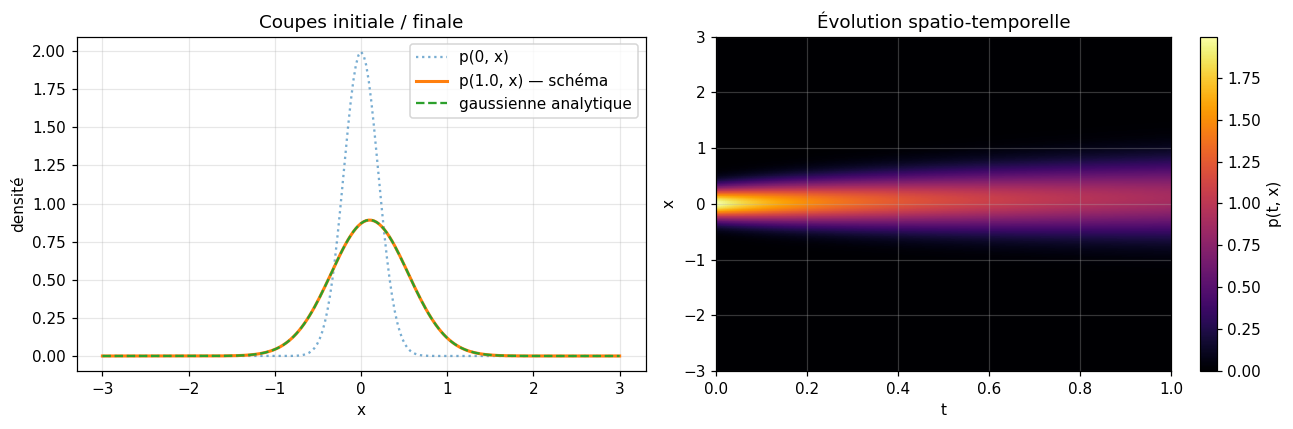

In [2]:
mu, sigma_sq, init_sigma = 0.1, 0.16, 0.2
T, n_t = 1.0, 200
n_x = 201
res = opt.fokker_planck_constant(mu, sigma_sq, init_sigma,
                                 -3.0, 3.0, n_x, T, n_t)
xs = np.array(res['x_grid'])
ts = np.array(res['time_grid'])
density = np.array(res['density']).reshape(n_t + 1, n_x)
p_final = density[-1]

# ground truth gaussienne
sig_eff = np.sqrt(sigma_sq * T + init_sigma ** 2)
analytic = np.exp(-(xs - mu * T) ** 2 / (2 * sig_eff ** 2))
analytic /= np.trapezoid(analytic, xs)

err = float(np.max(np.abs(p_final - analytic)))
mass = float(np.trapezoid(p_final, xs))
print(f"Erreur sup |p_num - p_ana| = {err:.3e}")
print(f"Masse finale (≈ 1)         = {mass:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, density[0], ':', label='p(0, x)', alpha=0.6)
axes[0].plot(xs, p_final, lw=2, label=f'p({T}, x) — schéma')
axes[0].plot(xs, analytic, '--', lw=1.5, label='gaussienne analytique')
axes[0].set_xlabel('x'); axes[0].set_ylabel('densité')
axes[0].set_title("Coupes initiale / finale")
axes[0].legend()
im = axes[1].imshow(density.T, aspect='auto', origin='lower',
                    extent=[0, T, xs.min(), xs.max()],
                    cmap='inferno')
axes[1].set_xlabel('t'); axes[1].set_ylabel('x')
axes[1].set_title("Évolution spatio-temporelle")
plt.colorbar(im, ax=axes[1], label='p(t, x)')
fig.tight_layout(); plt.show()


**Résultat attendu.** Erreur sup faible et masse $\approx 1$.

**Lecture du graphique.** Gauche : pic initial fin (pointillé) qui
s'étale en gaussienne décalée vers la droite (drift $\mu T = 0.1$).
Droite : carte chaleur de $p(t, x)$, qui s'élargit dans le temps.

**Conclusion.** Le solveur Fokker–Planck est validé sur le cas
gaussien.


## Cellule 2 — Poisson 2D sur un carré (équation harmonique)

**Théorème (Poisson Dirichlet).** Pour $f$ régulière et conditions
nulles sur $\partial\Omega = [0,1]^2$, $-\Delta u = f$ admet une
unique solution dans $H^1_0$.

**Équation pivot.** Si $f = 2\pi^2 \sin(\pi x)\sin(\pi y)$ alors
$$u(x, y) = \sin(\pi x)\sin(\pi y).$$

**Démonstration.** Calcul direct : $-\Delta u = 2\pi^2 \sin(\pi x)
\sin(\pi y) = f$.  $\square$

**Ce que la cellule vérifie.** Le solveur SOR `poisson_2d_zero_boundary`
résout l'équation et l'erreur tend vers zéro.


Itérations SOR : 290
Résidu final   : 9.737e-07
Erreur sup     : 4.896e-04


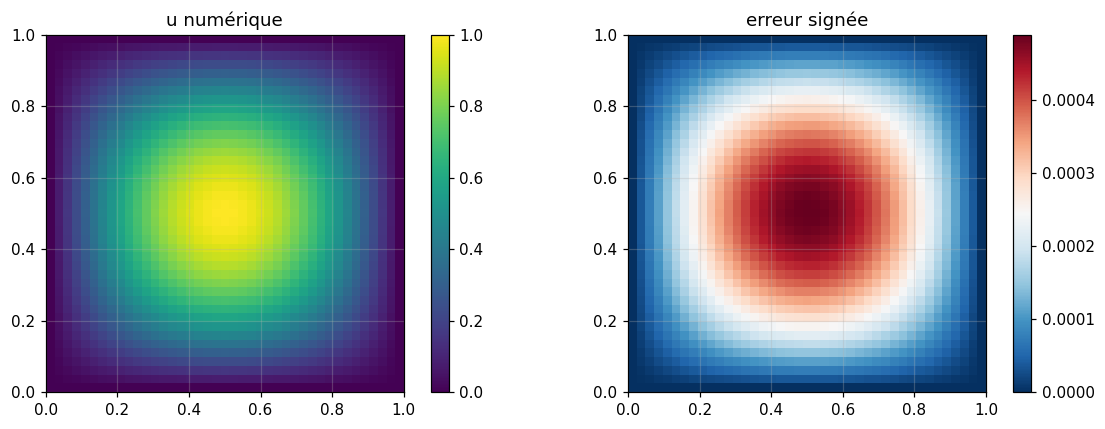

In [3]:
nx_grid = 41
xs = ys = np.linspace(0, 1, nx_grid)
X, Y = np.meshgrid(xs, ys, indexing='ij')
f = 2 * np.pi ** 2 * np.sin(np.pi * X) * np.sin(np.pi * Y)
res = opt.poisson_2d_zero_boundary(
    f.flatten().tolist(), nx_grid, nx_grid,
    0.0, 1.0, 0.0, 1.0,
)
u = np.array(res['u']).reshape(nx_grid, nx_grid)

u_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)
err = float(np.max(np.abs(u - u_exact)))
print(f"Itérations SOR : {res['iterations']}")
print(f"Résidu final   : {res['residual']:.3e}")
print(f"Erreur sup     : {err:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(u, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
axes[0].set_title('u numérique'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(u - u_exact, origin='lower',
                      extent=[0, 1, 0, 1], cmap='RdBu_r')
axes[1].set_title('erreur signée'); plt.colorbar(im1, ax=axes[1])
fig.tight_layout(); plt.show()


**Résultat attendu.** Erreur sup faible (< $10^{-2}$) ; résidu
SOR petit.

**Lecture du graphique.** Cloche centrée à hauteur $1$ ;
carte d'erreur quasi nulle, symétrique autour de zéro.

**Conclusion.** Le solveur elliptique est validé.


## Cellule 3 — Exemple concret : diffusion thermique sur une plaque

**Modèle physique.** Plaque carrée $[0,1]^2$ chauffée par une source
gaussienne au centre, conditions de Dirichlet nulles sur le bord.
Équilibre régi par
$$-\Delta u = q(x, y),\qquad u\big|_{\partial\Omega} = 0.$$

**Ce que la cellule vérifie.** Profil radial décroissant de température
sous source ponctuelle.


Température max au centre : 0.290
Température max au bord   : 0.00e+00
Itérations SOR            : 820


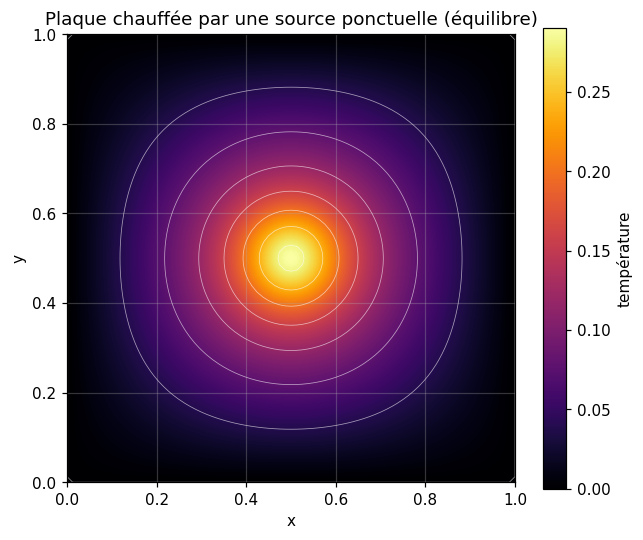

In [4]:
nx_grid = 81
xs = ys = np.linspace(0, 1, nx_grid)
X, Y = np.meshgrid(xs, ys, indexing='ij')
q = 50.0 * np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / (2 * 0.05 ** 2))
res = opt.poisson_2d_zero_boundary(
    q.flatten().tolist(), nx_grid, nx_grid,
    0.0, 1.0, 0.0, 1.0,
)
u = np.array(res['u']).reshape(nx_grid, nx_grid)

print(f"Température max au centre : {u.max():.3f}")
print(f"Température max au bord   : {u[0, :].max():.2e}")
print(f"Itérations SOR            : {res['iterations']}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(u, origin='lower', extent=[0, 1, 0, 1],
               cmap='inferno', interpolation='bilinear')
ax.contour(X, Y, u, levels=8, colors='white', linewidths=0.5, alpha=0.6)
ax.set_title("Plaque chauffée par une source ponctuelle (équilibre)")
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='température')
fig.tight_layout(); plt.show()


**Résultat attendu.** Température décroissante du centre vers le
bord (Dirichlet), profil radial visible.

**Lecture du graphique.** Iso-températures (lignes blanches) circulaires
autour de la source ; température nulle sur les bords.

**Conclusion.** Le même solveur Poisson 2D résout des problèmes
mathématiques académiques *et* des problèmes physiques concrets
(transfert thermique, électrostatique).
